In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("kukuroo3/nyc-motor-vehicle-collisions-to-person")

# print("Path to dataset files:", path)

In [4]:
url = 'https://docs.google.com/spreadsheets/d/1J6x8ynn9UPqgwiC_Eh0LadYQuyoIjpMkT4j_Itg5Apk/export?format=csv'

In [5]:
df = pd.read_csv(url)

In [6]:
df.head()
# df.info()

,CRASH_DATE,CRASH_TIME,PERSON_INJURY,PERSON_AGE,BODILY_INJURY,SAFETY_EQUIPMENT,PERSON_SEX,PERSON_TYPE,PED_LOCATION,CONTRIBUTING_FACTOR_2,...,COMPLAINT,EMOTIONAL_STATUS,VEHICLE_ID,PERSON_ID,CONTRIBUTING_FACTOR_1,POSITION_IN_VEHICLE,PED_ROLE,UNIQUE_ID,PED_ACTION,COLLISION_ID
0,2021-05-02,21:00,Killed,62.0,Head,NaN,F,Pedestrian,Pedestrian/Bicyclist/Other Pedestrian at Inter...,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,...,Severe Bleeding,Apparent Death,NaN,f2f329b6-2dfc-4bd0-b751-2e4255f1ea06,Traffic Control Disregarded,NaN,Pedestrian,11791937,Crossing Against Signal,4412948
1,2021-05-21,0:00,Killed,24.0,Entire Body,Air Bag Deployed,M,Occupant,NaN,NaN,...,Internal,Apparent Death,19986231.0,e27e12a2-0485-4e22-b692-3f8a765d2582,NaN,Driver,Driver,11819198,NaN,4419608
2,2021-10-15,2:00,Killed,30.0,Head,NaN,M,Occupant,NaN,NaN,...,Internal,Apparent Death,20091024.0,1a6f5aa7-5125-4be2-8499-fe7977cb0d90,NaN,Driver,Driver,11998317,NaN,4467504
3,2021-04-17,13:00,Killed,71.0,Head,NaN,M,Pedestrian,Pedestrian/Bicyclist/Other Pedestrian Not at I...,Unspecified,...,Internal,Unconscious,NaN,b950706b-00a4-485c-84c5-777208cc3cc9,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,NaN,Pedestrian,11745791,"Crossing, No Signal, or Crosswalk",4408062
4,2021-05-25,22:00,Killed,69.0,Entire Body,NaN,F,Pedestrian,Pedestrian/Bicyclist/Other Pedestrian Not at I...,Unspecified,...,None Visible,Conscious,NaN,6504ea0a-c92d-444c-8127-284943be9aac,Unspecified,NaN,Pedestrian,11991283,"Crossing, No Signal, Marked Crosswalk",4420918


# **1. Data Cleaning**


1.1. Checking for duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

1.2. Checking for NaN values

In [8]:
df.isnull().sum()

,0
CRASH_DATE,0
CRASH_TIME,0
PERSON_INJURY,0
PERSON_AGE,421
BODILY_INJURY,0
SAFETY_EQUIPMENT,12177
PERSON_SEX,0
PERSON_TYPE,0
PED_LOCATION,39098
CONTRIBUTING_FACTOR_2,39123


1.3. Correcting columns one by one

1.3.1. Column **"PERSON_AGE"**


In [9]:
print(f"Column 'PERSON_AGE'")

df['PERSON_AGE'] = df['PERSON_AGE'].fillna(df["PERSON_AGE"].mean()).round()
print (f"Verifying 0 null values in the 'PERSON_AGE' column: \nnull values in the column:{df['PERSON_AGE'].isnull().sum()}")
# print(f"Unique values:{df['PERSON_AGE'].nunique()}")

Column 'PERSON_AGE'
Verifying 0 null values in the 'PERSON_AGE' column: 
null values in the column:0


1.3.2. Column **"SAFETY_EQUIPMENT"**

In [10]:
print(f"\nColumn 'SAFETY_EQUIPMENT'")

df['SAFETY_EQUIPMENT'] = df['SAFETY_EQUIPMENT'].fillna('Unknown')
print (f"Verifying 0 null values in the 'SAFETY_EQUIPMENT' column: \nnull values in the column:{df['SAFETY_EQUIPMENT'].isnull().sum()}")
# print(f"Unique values:{df['SAFETY_EQUIPMENT'].nunique()}")


Column 'SAFETY_EQUIPMENT'
Verifying 0 null values in the 'SAFETY_EQUIPMENT' column: 
null values in the column:0


1.3.3. Column **"PED_LOCATION"**

In [11]:
print(f"\nColumn 'PED_LOCATION'")

df['PED_LOCATION'] = df['PED_LOCATION'].fillna('Does Not Apply')
df['PED_LOCATION'] = df['PED_LOCATION'].replace('Unknown', 'Does Not Apply')
# print(df.PED_LOCATION.unique().tolist())
print (f"Verifying 0 null values in the 'SAFETY_EQUIPMENT' column: \nnull values in the column:{df['PED_LOCATION'].isnull().sum()}")
# print(f"Unique values:{df['PED_LOCATION'].nunique()}")


Column 'PED_LOCATION'
Verifying 0 null values in the 'SAFETY_EQUIPMENT' column: 
null values in the column:0


1.3.4 & 1.3.5 Columns **"CONTRIBUTING_FACTOR_1"** and **"CONTRIBUTING_FACTOR_2"**

In [12]:
df['CONTRIBUTING_FACTOR_1'] = df['CONTRIBUTING_FACTOR_1'].fillna('Does Not Apply')
df['CONTRIBUTING_FACTOR_1'] = df['CONTRIBUTING_FACTOR_1'].replace('Unspecified', 'Does Not Apply')

# To view the repeating contributing 1 factors, run
# pd.Series(df['CONTRIBUTING_FACTOR_1'].unique())

df['CONTRIBUTING_FACTOR_2'] = df['CONTRIBUTING_FACTOR_2'].fillna('Does Not Apply')
df['CONTRIBUTING_FACTOR_2'] = df['CONTRIBUTING_FACTOR_2'].replace('Unspecified', 'Does Not Apply')

# To view the repeating contributing 2 factors, run
# pd.Series(df['CONTRIBUTING_FACTOR_2'].unique())

1.3.6. Column **"PED_ACTION"**

In [13]:
df['PED_ACTION'] = df['PED_ACTION'].fillna('Does Not Apply')
df['PED_ACTION'] = df['PED_ACTION'].replace('Unknown', 'Does Not Apply')

# To view the repeating values for the PED_ACTION column, run
# pd.Series(df.PED_ACTION.unique().tolist())

1.3.7. Column **"POSITION_IN_VEHICLE"**

In [14]:
df["POSITION_IN_VEHICLE"] = df["POSITION_IN_VEHICLE"].fillna("Does Not Apply")
df["POSITION_IN_VEHICLE"] = df["POSITION_IN_VEHICLE"].replace("Unknown", "Does Not Apply")

# To view the repeating values for the POSITION_IN_VEHICLE column, run
# pd.Series(df.PED_ACTION.unique().tolist())

1.3.8. Column **"EJECTION"**

Fill the missing values with the mode of the column, which in this case is the **"Not Ejected"** value taking more than 78% of occurences in the column values

In [15]:
# df.EJECTION.value_counts()[0]/df.shape[0] * 100
# df.EJECTION.value_counts()

df['EJECTION'] = df['EJECTION'].fillna('Not Ejected')
# df.EJECTION.value_counts()

# additional possibly important information / code used in process
# df.EJECTION.isnull().sum()
# pd.Series(df.EJECTION.unique().tolist())
# df.EJECTION.mode()

1.3.9. Column **"VEHICLE_ID"**

In [16]:
df["VEHICLE_ID"] = df["VEHICLE_ID"].fillna("Does Not Apply")
df["VEHICLE_ID"] = df["VEHICLE_ID"].replace("Unknown", "Does Not Apply")

# To view the repeating values for the POSITION_IN_VEHICLE column, run
# (df.VEHICLE_ID.unique().tolist())

### 🎉 **OUR DATASET IS CLEAN** !!!

In [17]:
df.isnull().sum()

,0
CRASH_DATE,0
CRASH_TIME,0
PERSON_INJURY,0
PERSON_AGE,0
BODILY_INJURY,0
SAFETY_EQUIPMENT,0
PERSON_SEX,0
PERSON_TYPE,0
PED_LOCATION,0
CONTRIBUTING_FACTOR_2,0


1.4. Several adjustments for the finally clean dataset

1.4.1. Check data types

In [18]:
df.dtypes

,0
CRASH_DATE,object
CRASH_TIME,object
PERSON_INJURY,object
PERSON_AGE,float64
BODILY_INJURY,object
SAFETY_EQUIPMENT,object
PERSON_SEX,object
PERSON_TYPE,object
PED_LOCATION,object
CONTRIBUTING_FACTOR_2,object


1.4.2. Transform **"CRASH_DATE"** and **"CRASH_TIME"** into a more applicable data type, and

1.4.3. Merge them into **"CRASH_DATE_TIME"** to make the further analysis more effective.

We will remove the crash_date and crash_time columns later, before starting(see 1.4.7).

In [19]:
df['CRASH_DATE_TIME'] = df['CRASH_DATE'] + ' ' + df['CRASH_TIME']
pd.to_datetime(df.CRASH_DATE_TIME)
df['CRASH_DATE_TIME'] = pd.to_datetime(df.CRASH_DATE_TIME)
df['CRASH_DATE_TIME']

,CRASH_DATE_TIME
0,2021-05-02 21:00:00
1,2021-05-21 00:00:00
2,2021-10-15 02:00:00
3,2021-04-17 13:00:00
4,2021-05-25 22:00:00
...,...
45664,2021-05-07 00:00:00
45665,2021-04-27 13:00:00
45666,2021-05-07 14:00:00
45667,2021-05-10 16:00:00


Additional checking for correct values

1.4.4. Check for the values of **"PERSON_SEX"** column

1.4.5 Check for the values of **"BODILY_INJURY"** column


In [20]:
print(df.PERSON_SEX.unique())
print(df.BODILY_INJURY.unique())

['F' 'M' 'U']
['Head' 'Entire Body' 'Chest' 'Unknown' 'Abdomen - Pelvis' 'Back'
 'Knee-Lower Leg Foot' 'Neck' 'Does Not Apply' 'Shoulder - Upper Arm'
 'Elbow-Lower-Arm-Hand' 'Face' 'Hip-Upper Leg' 'Eye']


1.4.6. Removing all **"PERSON_AGE"** values which are out of logic

In [21]:
print((df['PERSON_AGE'] < 0).sum())
df.loc[df['PERSON_AGE'] < 0, 'PERSON_AGE'] = np.nan
df.loc[df['PERSON_AGE'] > 99, 'PERSON_AGE'] = np.nan

df['PERSON_AGE'].describe().round(2)

15


,PERSON_AGE
count,45633.00
mean,36.78
std,16.48
min,0.00
25%,25.00
50%,34.00
75%,48.00
max,99.00


After this we went back and re-run 1.3.1 to fill all the nan values with "Unknown"-s

In [22]:
df['PERSON_AGE'] = df['PERSON_AGE'].fillna(df["PERSON_AGE"].mean()).round()

df['PERSON_AGE'] = df['PERSON_AGE'].fillna(df["PERSON_AGE"].mean()).round()

In [23]:
print(f"Column 'PERSON_AGE'")

df['PERSON_AGE'] = df['PERSON_AGE'].fillna(df["PERSON_AGE"].mean()).round()
print (f"Verifying 0 null values in the 'PERSON_AGE' column: \nnull values in the column:{df['PERSON_AGE'].isnull().sum()}")
# print(f"Unique values:{df['PERSON_AGE'].nunique()}")

Column 'PERSON_AGE'
Verifying 0 null values in the 'PERSON_AGE' column: 
null values in the column:0


1.4.7. **Hide unnecessary columns for data analysis**
- Hiding **ID**-s because they simly enumerate the cases, and
- hiding **CRASH_DATE** and **CRASH_TIME** because we've created a single **CRASH_DATE_TIME** column, combining both.

In [24]:
analysis_df = df.drop(columns = ["VEHICLE_ID", "PERSON_ID", "UNIQUE_ID", "COLLISION_ID", "CRASH_DATE", "CRASH_TIME"])

In [25]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45669 entries, 0 to 45668
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   CRASH_DATE             45669 non-null  object        
 1   CRASH_TIME             45669 non-null  object        
 2   PERSON_INJURY          45669 non-null  object        
 3   PERSON_AGE             45669 non-null  float64       
 4   BODILY_INJURY          45669 non-null  object        
 5   SAFETY_EQUIPMENT       45669 non-null  object        
 6   PERSON_SEX             45669 non-null  object        
 7   PERSON_TYPE            45669 non-null  object        
 8   PED_LOCATION           45669 non-null  object        
 9   CONTRIBUTING_FACTOR_2  45669 non-null  object        
 10  EJECTION               45669 non-null  object        
 11  COMPLAINT              45669 non-null  object        
 12  EMOTIONAL_STATUS       45669 non-null  object        
 13  V

1.5. Logic errors

Here, as you can see, we have recorded helmet on an Bicyclist, lap beld on a pedestrian, and so on.

We will correct those logical errors now

In [26]:
df.groupby('PERSON_TYPE')['SAFETY_EQUIPMENT'].value_counts()

PERSON_TYPE      SAFETY_EQUIPMENT                        
Bicyclist        Unknown                                      3131
                 Helmet Only (In-Line Skater/Bicyclist)        812
                 Helmet/Other (In-Line Skater/Bicyclist)       229
                 Helmet (Motorcycle Only)                      155
                 Other                                          92
                 Lap Belt & Harness                             30
                 Lap Belt                                        6
                 Pads Only (In-Line Skater/Bicyclist)            4
                 Stoppers Only (In-Line Skater/Bicyclist)        3
                 Harness                                         2
Occupant         Lap Belt & Harness                          18134
                 Unknown                                      8090
                 Lap Belt                                     3693
                 Air Bag Deployed/Lap Belt/Harness             926
                 Helmet (Motorcycle Only)                      835
                 Child Restraint Only                          490
                 Air Bag Deployed                              261
                 Air Bag Deployed/Lap Belt                     145
                 Other                                         104
                 Harness                                       101
                 Helmet Only (In-Line Skater/Bicyclist)         59
                 Helmet/Other (In-Line Skater/Bicyclist)        35
                 Air Bag Deployed/Child Restraint               26
                 Pads Only (In-Line Skater/Bicyclist)            3
                 Stoppers Only (In-Line Skater/Bicyclist)        1
Other Motorized  Unknown                                      1380
                 Helmet (Motorcycle Only)                      212
                 Helmet Only (In-Line Skater/Bicyclist)        174
                 Helmet/Other (In-Line Skater/Bicyclist)        61
                 Other                                          28
                 Lap Belt & Harness                             15
                 Lap Belt                                       11
                 Pads Only (In-Line Skater/Bicyclist)            4
                 Harness                                         1
                 Stoppers Only (In-Line Skater/Bicyclist)        1
Pedestrian       Unknown                                      6394
                 Other                                           9
                 Lap Belt & Harness                              5
                 Helmet (Motorcycle Only)                        3
                 Helmet Only (In-Line Skater/Bicyclist)          2
                 Helmet/Other (In-Line Skater/Bicyclist)         1
                 Lap Belt                                        1
Name: count, dtype: int64

In [27]:
# Bicyclist
df.loc[(df.PERSON_TYPE == "Bicyclist") & (df.SAFETY_EQUIPMENT.isin([
                                                                    'Lap Belt','Harness','Lap Belt & Harness', 'Helmet (Motorcycle Only)'
                                                                    ])), 'SAFETY_EQUIPMENT'] = np.nan

# Occupant
df.loc[(df.PERSON_TYPE == "Occupant") & (df.SAFETY_EQUIPMENT.isin([
                                                                    'Helmet (Motorcycle Only)', 'Helmet Only (In-Line Skater/Bicyclist)',
                                                                    'Helmet/Other (In-Line Skater/Bicyclist)','Pads Only (In-Line Skater/Bicyclist)',
                                                                    'Stoppers Only (In-Line Skater/Bicyclist)'
                                                                    ])), 'SAFETY_EQUIPMENT'] = np.nan
# Other Motorized
df.loc[(df.PERSON_TYPE == "Other Motorized") & (df.SAFETY_EQUIPMENT.isin([
                                                                    'Helmet Only (In-Line Skater/Bicyclist)', 'Helmet/Other (In-Line Skater/Bicyclist)',
                                                                    ])), 'SAFETY_EQUIPMENT'] = np.nan
# Pedestrian
df.loc[(df.PERSON_TYPE == "Pedestrian") & (df.SAFETY_EQUIPMENT.isin([
                                                                    'Lap Belt','Harness','Lap Belt & Harness', 'Helmet (Motorcycle Only)',
                                                                    'Helmet Only (In-Line Skater/Bicyclist)', 'Helmet/Other (In-Line Skater/Bicyclist)'
                                                                    ])), 'SAFETY_EQUIPMENT'] = np.nan

The actual code for correcting logic errors.

Note that it is important to go back to 1.3.2. to make all NaN values "Unknown" again.

In [28]:
print(f"\nColumn 'SAFETY_EQUIPMENT'")

df['SAFETY_EQUIPMENT'] = df['SAFETY_EQUIPMENT'].fillna('Unknown')
print (f"Verifying 0 null values in the 'SAFETY_EQUIPMENT' column: \nnull values in the column:{df['SAFETY_EQUIPMENT'].isnull().sum()}")
# print(f"Unique values:{df['SAFETY_EQUIPMENT'].nunique()}")


Column 'SAFETY_EQUIPMENT'
Verifying 0 null values in the 'SAFETY_EQUIPMENT' column: 
null values in the column:0


In [29]:
# final check
df.isnull().sum()

,0
CRASH_DATE,0
CRASH_TIME,0
PERSON_INJURY,0
PERSON_AGE,0
BODILY_INJURY,0
SAFETY_EQUIPMENT,0
PERSON_SEX,0
PERSON_TYPE,0
PED_LOCATION,0
CONTRIBUTING_FACTOR_2,0


In [30]:
df = df.replace("Does Not Apply", "Unknown")

In [31]:
# remember that
cleaned_df = df.drop(columns = ["VEHICLE_ID", "PERSON_ID", "UNIQUE_ID", "COLLISION_ID", "CRASH_DATE", "CRASH_TIME"])

# **2. Classes**

# **2.1. Data Analyzer**

In [32]:
class Analyzer:
  """
    A class to perform analysis for our cleaned dataframe
  """
  def __init__(self, df, name):
    """
        Initializing the Analyzer class with reference to our cleaned dataframe
        Args used: df (dataframe) that is our cleaned dataframe
                   name (string) that is the title of cleaned dataframe
    """
    self.df = df
    self.name = name
    # Two attributes: 1st the dataframe itself, 2nd the name of that dataframe

  def crashes_every_month(self):
    """
    Returns the statistics of crashes for every month of the given dataframe.
    """
    month_names = self.df['CRASH_DATE_TIME'].dt.month_name()
    print(month_names)
    result = month_names.value_counts()
    return result


  def crashes_by_person_type(self):
    """
    Returns the statistics of crashes based on person type of the given dataframe.
    """
    # Statistics of crashes based on person type, e.g. bicyclist, pedestrian
    result = self.df.groupby("PERSON_TYPE").size().copy()
    return result

  def crashes_by_age_sex(self):
    """
    Returns the difference of statistics of crashes' mean, median, mode for male and female of the given dataframe.
    """
    # Statistics of person's age mean, median and mode of crashes and the difference between male and female
    result = self.df.groupby("PERSON_SEX")["PERSON_AGE"].agg(["mean", "median", pd.Series.mode]).drop("U").copy()
    # Dropping the row of unknown sex
    return result

  def cor_role_injury(self):
    """
    Returns the correlation of person's role and injury type of the given dataframe.
    """
    # Correlation between person's role and injury
    result = self.df[["PERSON_INJURY", "PED_ROLE"]].copy()
    # result["PERSON_INJURY"] = result["PERSON_INJURY"].map({"Killed": 1, "Injured": 0})
    result = pd.get_dummies(result, columns=["PED_ROLE"])
    result = pd.get_dummies(result, columns=["PERSON_INJURY"])
    # heatmap can be created for this
    result = result.corr()
    result = result.loc[
      [col for col in result.columns if "PED_ROLE" in col],
      [col for col in result.columns if "PERSON_INJURY" in col]
    ]
    return result

  def cor_emotional_status_injury(self):
    """
    Returns the correlation of person's emotional status and injury type of the given dataframe.
    """
    # Correlation between emotional status and injury
    result = self.df[["PERSON_INJURY", "EMOTIONAL_STATUS"]].copy()
    # result["PERSON_INJURY"] = result["PERSON_INJURY"].map({"Killed": 1, "Injured": 0})
    result = pd.get_dummies(result, columns=["EMOTIONAL_STATUS"])
    result = pd.get_dummies(result, columns=["PERSON_INJURY"])
    # heatmap can be created for this
    result = result.corr()
    result = result.loc[
      [col for col in result.columns if "EMOTIONAL_STATUS" in col],
      [col for col in result.columns if "PERSON_INJURY" in col]
    ]
    return result

  def cor_factor_injury(self):
    """
    Returns the correlation of the contributing factor and injury type of the given dataframe.
    """
    # Correlation between contributing factor and injury
    result = self.df[["PERSON_INJURY", "CONTRIBUTING_FACTOR_1"]].copy()
    # result["PERSON_INJURY"] = result["PERSON_INJURY"].map({"Killed": 1, "Injured": 0})
    result = pd.get_dummies(result, columns=["CONTRIBUTING_FACTOR_1"])
    result = pd.get_dummies(result, columns=["PERSON_INJURY"])
    # heatmap can be created for this
    result = result.corr()
    result = result.loc[
      [col for col in result.columns if "CONTRIBUTING_FACTOR_1" in col],
      [col for col in result.columns if "PERSON_INJURY" in col]
    ]
    return result

In [33]:
nyc = Analyzer(cleaned_df, "NYC Collisions")
# Creating an instance of Analyzer class to be later used


0             May
1             May
2         October
3           April
4             May
           ...   
45664         May
45665       April
45666         May
45667         May
45668    November
Name: CRASH_DATE_TIME, Length: 45669, dtype: object


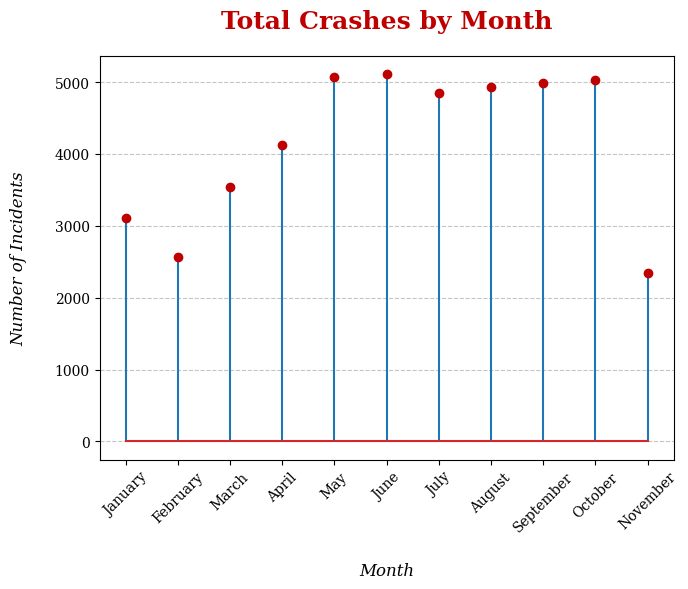

In [34]:
class Visualization:

    """
    A class to perform visual representations of our analysis results
    """

    def __init__(self, analyzer):
        """
        Initializing the Visualization class with reference to Analyzer class
        Args used: analyzer(Analizer) that is an instance of Analyzer class which contains data we want to vizualize
        """
        self.analyzer = analyzer

#1.monthly crashes linear plot
    def plot_monthly_crashes(self):
        """
        Generate a bar chart showing the number of crashes per month
        """
        monthly_counts = self.analyzer.crashes_every_month()

        months_order = ["January", "February", "March", "April", "May", "June",
                        "July", "August", "September", "October", "November"]

        #make sure the order is correct
        monthly_counts = monthly_counts.reindex(months_order).dropna()
        order = np.arange(11)

        plt.figure(figsize=(7, 6))
        # plt.plot(monthly_counts.index, monthly_counts.values, marker='o', color='blue', linewidth=2)
        plt.stem(monthly_counts.values, markerfmt='#BF0000')
        plt.xticks(order, months_order, rotation=45, fontname="serif", fontsize=10)
        plt.yticks(fontname="serif")
        plt.title("Total Crashes by Month", fontsize=18, fontname="serif", fontweight="bold", color="#BF0000", pad=20)
        plt.xlabel("Month", fontsize=12, fontname="serif", labelpad=20, style="italic")
        plt.ylabel("Number of Incidents", fontsize=12, fontname="serif", labelpad=20, style="italic")
        plt.grid(axis="y", linestyle="--", alpha=0.75)
        plt.tight_layout()
        plt.show()


#2. Bar chart for easy comparison of groups
#looked at the PERSON_TYPE column and count occurrences of Driver, Passenger, Pedestrian and so on
    def plot_person_type_dist(self):
        """
        Creates a pie chart to vizualize the proportion of differfent persons types involved in collisions
        """
        #get the data
        person_type_counts = self.analyzer.crashes_by_person_type()

        #plot-code
        pie_colors = ["#ff6853", "#ffb514", "#51d11a", "#55a9ff"]
        plt.figure(figsize=(8, 8))
        patches, texts, autotexts = plt.pie(person_type_counts.values, colors=pie_colors, labels=person_type_counts.index, autopct='%1.1f%%', startangle=140, textprops={'fontname': 'serif', 'fontsize': 11, 'color': 'blue'}, shadow=True, explode=(0.1, 0.1, 0.1, 0.1))
        plt.title("Distribution of Crashes by Person Type", fontsize=18, fontname="serif", fontweight="bold", color="#FD5800", pad=32)
        for t in texts:
          t.set_color('#ffb514')
          t.set_size(12)
          t.set_weight('bold')
          t.set_style('italic')
        for at in autotexts:
          at.set_color('white')
          at.set_size(11)
          at.set_weight('bold')
        plt.show()
#3mean, median, and mode in genders
    def plot_age_sex_stats(self):
        """
        Creates a bar chart to vizualize the difference of statistics of crashes' mean, median, mode for male and female
        """

        age_stats = self.analyzer.crashes_by_age_sex().T
        age_stats.plot(kind="bar", figsize=(10, 6), color=["#FF007E", "#2431A1"])

        plt.title("Age Statistics by Gender", fontsize=18, fontname="serif", fontweight="bold", pad=25)
        plt.xlabel("Gender (F is Female, M is Male)", fontsize=12, fontname="serif", labelpad=20, style="italic")
        plt.ylabel("Age", fontsize=12, fontname="serif", labelpad=20, style="italic")

        plt.xticks(rotation=0, fontname="serif", fontsize=12)
        plt.yticks(fontname="serif", fontsize=12)

        plt.show()

#4.Correlation between persons role and injury
    def plot_role_injury_corr(self):
        """
        Makes a heatmap representing the correlation between persons role and injury
        """

        #get the data from the analyzer
        role_data = self.analyzer.cor_role_injury()

        #clean the labels
        role_data.index = role_data.index.str.replace("PED_ROLE_", "")
        role_data.columns = role_data.columns.str.replace("PERSON_INJURY_", "")

        df_melted = role_data.reset_index().melt(id_vars=role_data.index.name or 'index')
        df_melted.columns = ['Role', 'Injury', 'Correlation']

        #plot the scatterplot
        plt.figure(figsize=(3, 5))     #SEABORN
        sns.scatterplot(
            data=df_melted,
            x="Injury",
            y="Role",
            size="Correlation",
            hue="Correlation",
            sizes=(20, 500),
            palette="coolwarm"
        )

        plt.title("Correlation - Person Role VS Injury Type", fontsize=15, fontname="serif", fontweight="bold", pad=25)
        plt.xlabel("Injury", fontsize=12, fontname="serif", labelpad=20, style="italic")
        plt.ylabel("Role", fontsize=12, fontname="serif", labelpad=20, style="italic")
        plt.xticks(rotation=0, fontname="serif", fontsize=10)
        plt.yticks(fontname="serif", fontsize=10)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


#5.Correlation between emotional status and injury
    def plot_emotional_injury_corr(self):
        """
        Generates a heatmap to vizualize the correlation between persons role and injury
        """
        emo_corr = self.analyzer.cor_emotional_status_injury()

        emo_corr.index = emo_corr.index.str.replace("EMOTIONAL_STATUS_", "")
        emo_corr.columns = emo_corr.columns.str.replace("PERSON_INJURY_", "")

        plt.figure(figsize=(5, 6))
        sns.heatmap(emo_corr, annot=True, cmap="Greens", linewidths=0.7, annot_kws={"font": "serif", "size": 10, "style": "italic"})  #SEABORN
        plt.title("Impact of Emotional Status on Injury Type", fontsize=15, color="#14452F" ,fontname="serif", fontweight="bold", pad=25)
        plt.xticks(rotation=0, fontname="serif", fontsize=10)
        plt.yticks(fontname="serif", fontsize=10)
        plt.show()


#6. corredlation between injury and factor
    def plot_top_factors_corr(self):
        """
        Makes a grid chart showing the correlation between contributing factors and injury
        """
        factor_data = self.analyzer.cor_factor_injury()
        factor_data.index = factor_data.index.str.replace("CONTRIBUTING_FACTOR_1_", "")

        #get top-10 factors
        top_10_factors = factor_data.iloc[:, 0].sort_values(ascending=True).tail(10)

        #horizontal bar chart
        plt.figure(figsize=(10, 5))
        top_10_factors.plot(kind="barh", color="red", edgecolor="black")

        plt.title("Top 10 Most Dangerous Contributing Factors", fontsize=15, fontname="serif", fontweight="bold", pad=25)
        plt.xlabel("Correlation Strength", fontname="serif", labelpad=20, style="italic", fontsize=12)
        plt.ylabel("Factor", fontname="serif", labelpad=20, style="italic", fontsize=12)
        plt.xticks(fontname="serif", fontsize=10)
        plt.yticks(fontname="serif", fontsize=10)
        plt.show()



viz = Visualization(nyc)
viz.plot_monthly_crashes()

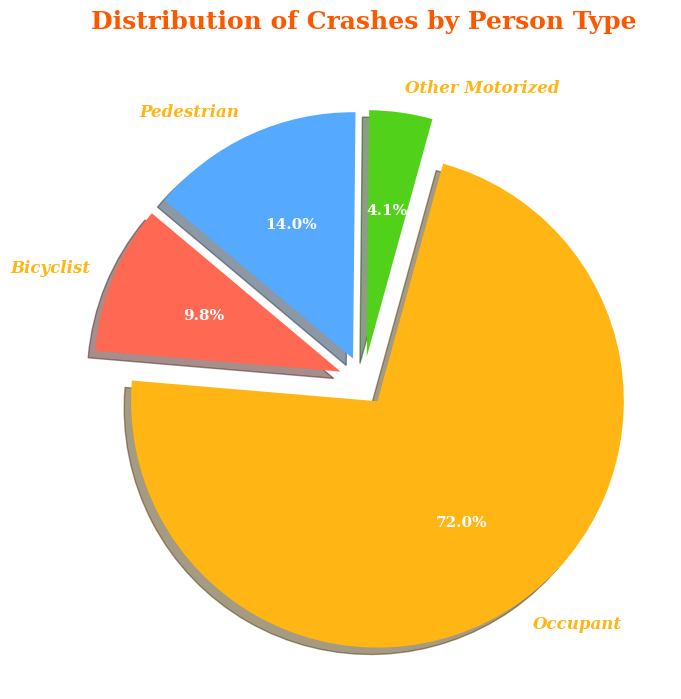

In [36]:
viz.plot_person_type_dist()

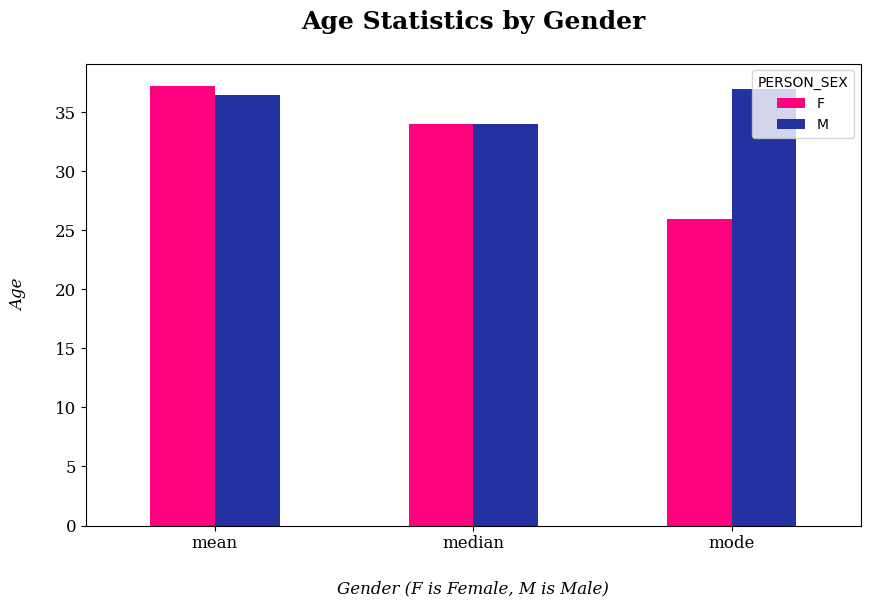

In [37]:
viz.plot_age_sex_stats()

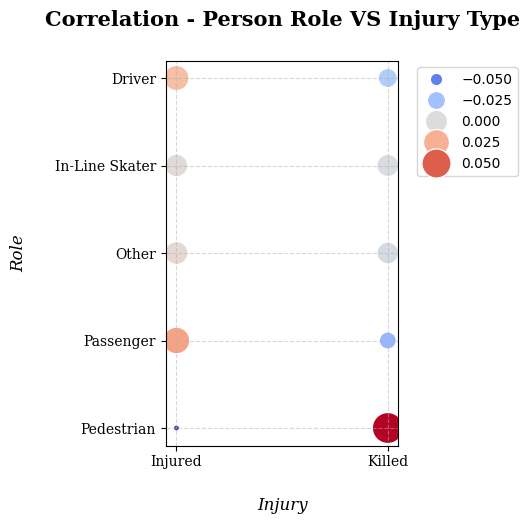

In [38]:
viz.plot_role_injury_corr()

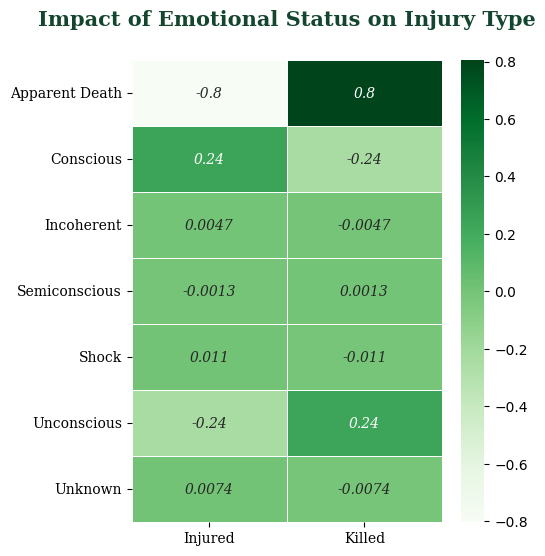

In [39]:
viz.plot_emotional_injury_corr()

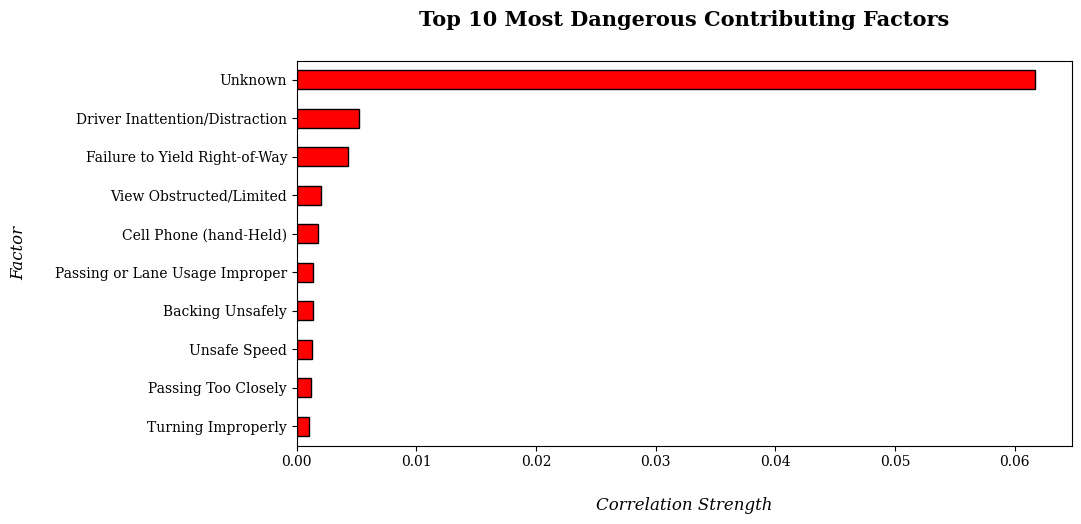

In [40]:
viz.plot_top_factors_corr()